<a href="https://colab.research.google.com/github/Joancarmya/Deep-Learning/blob/main/DL_lab7_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Imports and setup
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# 2. Load and preprocess MNIST
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

# Pixel values [0,255] -> [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full  = x_test_full.astype("float32")  / 255.0

# Recommended laboratory subset: 10,000 training images, 2,000 test images
N_TRAIN = 10000
N_TEST  = 2000

rng = np.random.default_rng(42)
train_idx = rng.choice(len(x_train_full), size=N_TRAIN, replace=False)
test_idx  = rng.choice(len(x_test_full),  size=N_TEST,  replace=False)

x_train = x_train_full[train_idx]          # (10000, 28, 28)
y_train = y_train_full[train_idx]
x_test  = x_test_full[test_idx]            # (2000, 28, 28)
y_test  = y_test_full[test_idx]

# Add channel dimension for convolutional models: (N, 28, 28, 1)
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn  = x_test[..., np.newaxis]

# Flattened versions for the fully connected autoencoder: (N, 784)
x_train_flat = x_train.reshape((-1, 784))
x_test_flat  = x_test.reshape((-1, 784))

print("Required preprocessing output:")
print(f"  Training images : {x_train_cnn.shape}")
print(f"  Testing images  : {x_test_cnn.shape}")
print(f"  Flattened train : {x_train_flat.shape}")
print(f"  Flattened test  : {x_test_flat.shape}")
print(f"  Pixel range     : [{x_train.min():.2f}, {x_train.max():.2f}]")

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Required preprocessing output:
  Training images : (10000, 28, 28, 1)
  Testing images  : (2000, 28, 28, 1)
  Flattened train : (10000, 784)
  Flattened test  : (2000, 784)
  Pixel range     : [0.00, 1.00]


In [ ]:
# 3. Build the Fully Connected Autoencoder
# Architecture: 784 -> 128 -> 32 -> 16 (latent) -> 32 -> 128 -> 784
LATENT_DIM_FC = 16

def build_fc_autoencoder(latent_dim=LATENT_DIM_FC):
    inputs = layers.Input(shape=(784,), name="fc_ae_input")
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(784, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="FC_Autoencoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model

fc_ae = build_fc_autoencoder()
fc_ae.summary()

Model: "FC_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc_ae_input (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.3585 - val_loss: 0.2609
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2420 - val_loss: 0.2221
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2089 - val_loss: 0.1971
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1882 - val_loss: 0.1787
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1711 - val_loss: 0.1634
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1601 - val_loss: 0.1554
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1537 - val_loss: 0.1504
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1494 - val_loss: 0.1469
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1460 - val_loss: 0.1439
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.1433 - val_loss: 0.1415
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.1410 - val_loss: 0.1395
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1

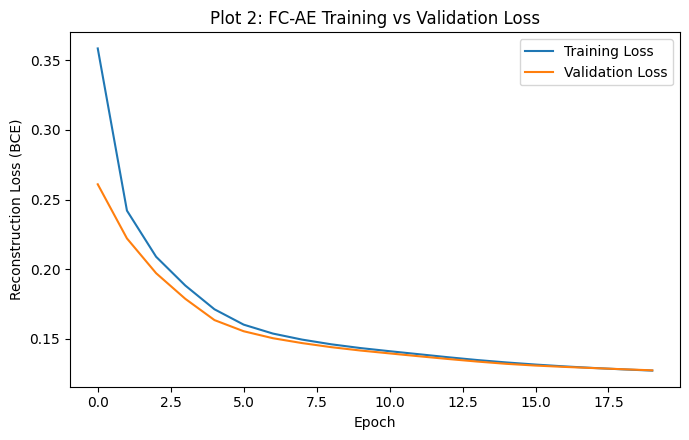

In [ ]:
# 4. Train the Fully Connected Autoencoder (20 epochs, batch size 128) and time it
start_time = time.time()
history_fc = fc_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20,
    batch_size=128,
    verbose=1
)
fc_train_time = time.time() - start_time
print(f"\nFC-AE training time: {fc_train_time:.2f} seconds")

# Plot 2: Training and Validation Reconstruction Loss (basic autoencoder)
plt.figure(figsize=(7, 4.5))
plt.plot(history_fc.history["loss"], label="Training Loss")
plt.plot(history_fc.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction Loss (BCE)")
plt.title("Plot 2: FC-AE Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/plot2_fc_ae_loss_curve.png", dpi=150)
plt.show()

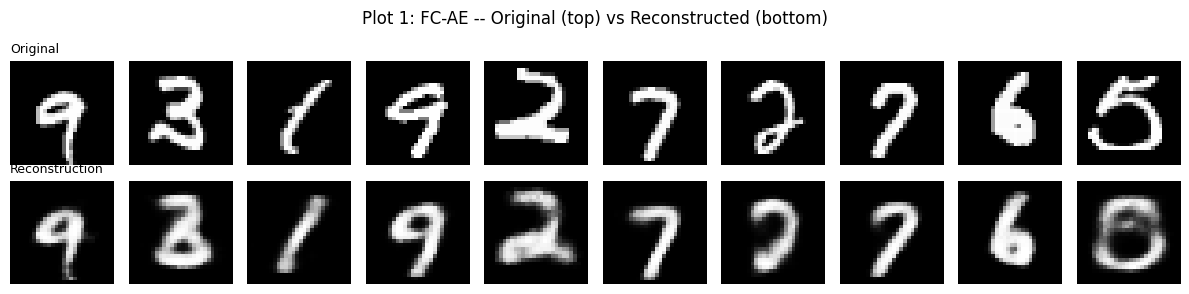

In [ ]:
# 5. Plot 1: Original versus Reconstructed Images (FC-AE), 10 test images
n_display = 10
recon_fc_flat = fc_ae.predict(x_test_flat[:n_display], verbose=0)
recon_fc_imgs = recon_fc_flat.reshape((-1, 28, 28))

fig, axes = plt.subplots(2, n_display, figsize=(n_display * 1.2, 3))
for i in range(n_display):
    axes[0, i].imshow(x_test[i], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_fc_imgs[i], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=9)
axes[1, 0].set_title("Reconstruction", loc="left", fontsize=9)
fig.suptitle("Plot 1: FC-AE -- Original (top) vs Reconstructed (bottom)")
plt.tight_layout()
plt.savefig("figures/plot1_fc_ae_original_vs_reconstructed.png", dpi=150)
plt.show()

In [ ]:
# 6. Reconstruction metrics for the FC-AE on the full test set: MSE, MAE, mean SSIM
recon_fc_test_flat = fc_ae.predict(x_test_flat, verbose=0)
recon_fc_test_imgs = recon_fc_test_flat.reshape((-1, 28, 28))

fc_mse = mean_squared_error(x_test_flat.flatten(), recon_fc_test_flat.flatten())
fc_mae = mean_absolute_error(x_test_flat.flatten(), recon_fc_test_flat.flatten())
fc_ssim_scores = [ssim(x_test[i], recon_fc_test_imgs[i], data_range=1.0) for i in range(len(x_test))]
fc_mean_ssim = float(np.mean(fc_ssim_scores))
fc_params = fc_ae.count_params()

print(f"FC-AE  Test MSE   : {fc_mse:.6f}")
print(f"FC-AE  Test MAE   : {fc_mae:.6f}")
print(f"FC-AE  Mean SSIM  : {fc_mean_ssim:.4f}")
print(f"FC-AE  Parameters : {fc_params}")

results_fc_ae = {
    "model": "FC_Autoencoder",
    "mse": float(fc_mse), "mae": float(fc_mae), "mean_ssim": fc_mean_ssim,
    "parameters": int(fc_params), "training_time_sec": fc_train_time,
    "history": {"loss": [float(v) for v in history_fc.history["loss"]],
                "val_loss": [float(v) for v in history_fc.history["val_loss"]]}
}
with open("results/results_fc_ae.json", "w") as f:
    json.dump(results_fc_ae, f, indent=2)
print("Saved results/results_fc_ae.json")

FC-AE  Test MSE   : 0.021511
FC-AE  Test MAE   : 0.057644
FC-AE  Mean SSIM  : 0.7565
FC-AE  Parameters : 211040
Saved results/results_fc_ae.json


In [ ]:
# 7. Build the Convolutional Autoencoder (CAE)
def build_conv_autoencoder():
    inputs = layers.Input(shape=(28, 28, 1), name="cae_input")
    # Encoder
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)          # 14x14x32
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)          # 7x7x64  (latent feature map)
    # Decoder
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                            # 14x14x64
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                            # 28x28x32
    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    model = keras.Model(inputs, outputs, name="Conv_Autoencoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model

cae = build_conv_autoencoder()
cae.summary()

Model: "Conv_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 8. Train the Convolutional Autoencoder (20 epochs, batch size 128) and time it
start_time = time.time()
history_cae = cae.fit(
    x_train_cnn, x_train_cnn,
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20,
    batch_size=128,
    verbose=1
)
cae_train_time = time.time() - start_time
print(f"\nCAE training time: {cae_train_time:.2f} seconds")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 35s 408ms/step - loss: 0.2185 - val_loss: 0.0987
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 528ms/step - loss: 0.0918 - val_loss: 0.0845
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 70s 379ms/step - loss: 0.0826 - val_loss: 0.0789
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 347ms/step - loss: 0.0786 - val_loss: 0.0760
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 351ms/step - loss: 0.0761 - val_loss: 0.0744
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - loss: 0.0746 - val_loss: 0.0733
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 342ms/step - loss: 0.0734 - val_loss: 0.0721
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 341ms/step - loss: 0.0725 - val_loss: 0.0715
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 358ms/step - loss: 0.0719 - val_loss: 0.0708
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 338ms/step - loss: 0.0713 - val_loss: 0.0705
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 340ms/step - loss: 0.0708 - val_loss: 0.0700
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41

CAE  Test MSE   : 0.002392
CAE  Test MAE   : 0.014598
CAE  Mean SSIM  : 0.9762
CAE  Parameters : 74497

Comparison Table (Section 11):
Model                      MSE       MAE      SSIM      Params
Fully Connected AE    0.021511  0.057644    0.7565      211040
Convolutional AE      0.002392  0.014598    0.9762       74497
Saved results/results_cae.json


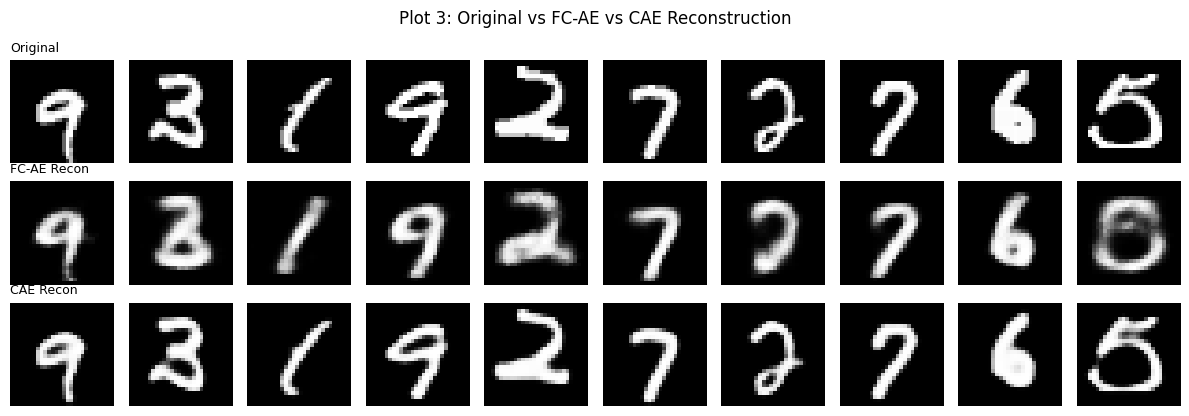

In [ ]:
# 9. CAE metrics, FC-AE vs CAE comparison table, and Plot 3
recon_cae_test = cae.predict(x_test_cnn, verbose=0)          # (N, 28, 28, 1)
recon_cae_test_imgs = recon_cae_test.squeeze(-1)

cae_mse = mean_squared_error(x_test_cnn.flatten(), recon_cae_test.flatten())
cae_mae = mean_absolute_error(x_test_cnn.flatten(), recon_cae_test.flatten())
cae_ssim_scores = [ssim(x_test[i], recon_cae_test_imgs[i], data_range=1.0) for i in range(len(x_test))]
cae_mean_ssim = float(np.mean(cae_ssim_scores))
cae_params = cae.count_params()

print(f"CAE  Test MSE   : {cae_mse:.6f}")
print(f"CAE  Test MAE   : {cae_mae:.6f}")
print(f"CAE  Mean SSIM  : {cae_mean_ssim:.4f}")
print(f"CAE  Parameters : {cae_params}")

print("\nComparison Table (Section 11):")
print(f"{'Model':<20}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Params':>12}")
print(f"{'Fully Connected AE':<20}{fc_mse:>10.6f}{fc_mae:>10.6f}{fc_mean_ssim:>10.4f}{fc_params:>12}")
print(f"{'Convolutional AE':<20}{cae_mse:>10.6f}{cae_mae:>10.6f}{cae_mean_ssim:>10.4f}{cae_params:>12}")

results_cae = {
    "model": "Conv_Autoencoder",
    "mse": float(cae_mse), "mae": float(cae_mae), "mean_ssim": cae_mean_ssim,
    "parameters": int(cae_params), "training_time_sec": cae_train_time,
    "history": {"loss": [float(v) for v in history_cae.history["loss"]],
                "val_loss": [float(v) for v in history_cae.history["val_loss"]]}
}
with open("results/results_cae.json", "w") as f:
    json.dump(results_cae, f, indent=2)
print("Saved results/results_cae.json")

# Plot 3: Original -> FC-AE Reconstruction -> CAE Reconstruction
n_display = 10
fig, axes = plt.subplots(3, n_display, figsize=(n_display * 1.2, 4.2))
for i in range(n_display):
    axes[0, i].imshow(x_test[i], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_fc_test_imgs[i], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(recon_cae_test_imgs[i], cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=9)
axes[1, 0].set_title("FC-AE Recon", loc="left", fontsize=9)
axes[2, 0].set_title("CAE Recon", loc="left", fontsize=9)
fig.suptitle("Plot 3: Original vs FC-AE vs CAE Reconstruction")
plt.tight_layout()
plt.savefig("figures/plot3_fc_vs_cae_reconstruction.png", dpi=150)
plt.show()

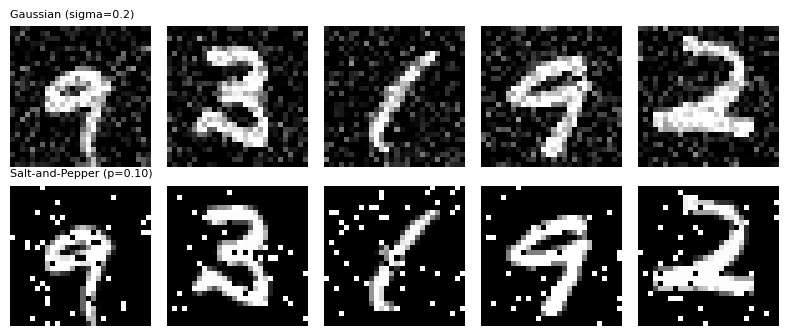

In [ ]:
# 10. Image corruption functions (Section 13): Gaussian noise and Salt-and-Pepper noise
def add_gaussian_noise(images, sigma, rng=None):
    rng = rng or np.random.default_rng(42)
    noisy = images + rng.normal(loc=0.0, scale=sigma, size=images.shape).astype(np.float32)
    return np.clip(noisy, 0.0, 1.0)

def add_salt_pepper_noise(images, p, rng=None):
    rng = rng or np.random.default_rng(42)
    noisy = images.copy()
    mask = rng.random(images.shape)
    noisy[mask < (p / 2)] = 0.0          # "pepper"
    noisy[(mask >= (p / 2)) & (mask < p)] = 1.0   # "salt"
    return noisy

# Quick visual sanity check of both corruption types at a moderate level
rng = np.random.default_rng(42)
demo_gauss = add_gaussian_noise(x_test_cnn[:5], sigma=0.2, rng=rng)
demo_sp    = add_salt_pepper_noise(x_test_cnn[:5], p=0.10, rng=rng)

fig, axes = plt.subplots(2, 5, figsize=(8, 3.4))
for i in range(5):
    axes[0, i].imshow(demo_gauss[i].squeeze(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(demo_sp[i].squeeze(), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("Gaussian (sigma=0.2)", loc="left", fontsize=8)
axes[1, 0].set_title("Salt-and-Pepper (p=0.10)", loc="left", fontsize=8)
plt.tight_layout()
plt.savefig("figures/noise_types_demo.png", dpi=150)
plt.show()

In [ ]:
# 11. Build and train two Denoising Convolutional Autoencoders (same architecture as Section 10):
#     one trained against Gaussian noise, one trained against Salt-and-Pepper noise.
#     In both cases the TARGET remains the clean image (Section 12).

def build_denoising_cae():
    # identical architecture to the plain CAE
    return build_conv_autoencoder()

rng = np.random.default_rng(42)

# --- Gaussian-noise denoiser ---
# Training noise: sigma drawn per-image from {0.1, 0.2, 0.3} so the model sees all levels
sigma_choices = rng.choice([0.1, 0.2, 0.3], size=len(x_train_cnn))
x_train_noisy_gauss = np.stack([
    add_gaussian_noise(x_train_cnn[i:i+1], sigma=sigma_choices[i], rng=rng)[0]
    for i in range(len(x_train_cnn))
])

denoise_gauss_model = build_denoising_cae()
start_time = time.time()
history_denoise_gauss = denoise_gauss_model.fit(
    x_train_noisy_gauss, x_train_cnn,
    validation_split=0.1,
    epochs=20, batch_size=128, verbose=1
)
denoise_gauss_train_time = time.time() - start_time
print(f"\nGaussian denoising CAE training time: {denoise_gauss_train_time:.2f} seconds")

# --- Salt-and-pepper-noise denoiser ---
p_choices = rng.choice([0.05, 0.10, 0.20], size=len(x_train_cnn))
x_train_noisy_sp = np.stack([
    add_salt_pepper_noise(x_train_cnn[i:i+1], p=p_choices[i], rng=rng)[0]
    for i in range(len(x_train_cnn))
])

denoise_sp_model = build_denoising_cae()
start_time = time.time()
history_denoise_sp = denoise_sp_model.fit(
    x_train_noisy_sp, x_train_cnn,
    validation_split=0.1,
    epochs=20, batch_size=128, verbose=1
)
denoise_sp_train_time = time.time() - start_time
print(f"\nSalt-and-pepper denoising CAE training time: {denoise_sp_train_time:.2f} seconds")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 352ms/step - loss: 0.2779 - val_loss: 0.1321
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 345ms/step - loss: 0.1134 - val_loss: 0.1019
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 331ms/step - loss: 0.0972 - val_loss: 0.0930
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 342ms/step - loss: 0.0905 - val_loss: 0.0885
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 327ms/step - loss: 0.0869 - val_loss: 0.0855
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 347ms/step - loss: 0.0846 - val_loss: 0.0838
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 348ms/step - loss: 0.0831 - val_loss: 0.0827
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 335ms/step - loss: 0.0820 - val_loss: 0.0819
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 42s 349ms/step - loss: 0.0813 - val_loss: 0.0807
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 41s 350ms/step - loss: 0.0803 - val_loss: 0.0799
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 24s 343ms/step - loss: 0.0799 - val_loss: 0.0799
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 41

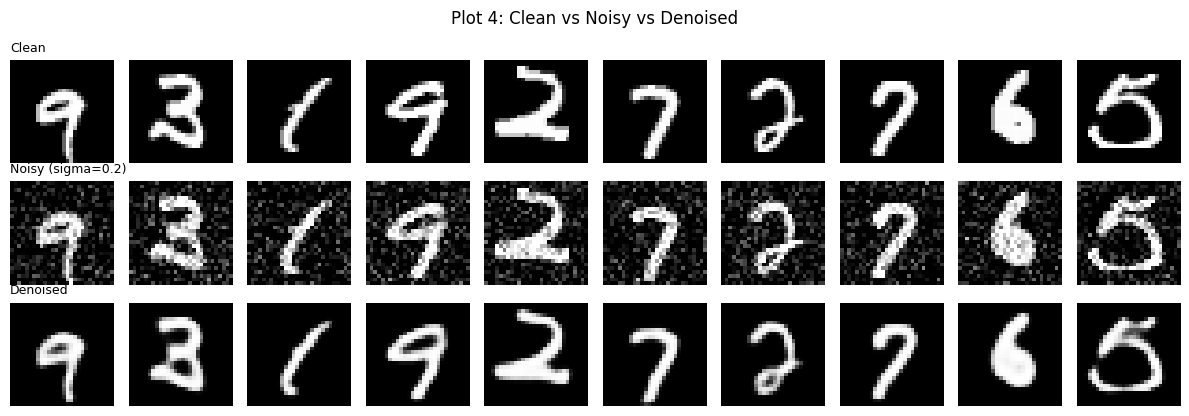

In [ ]:
# 12. Plot 4: Clean vs Noisy vs Denoised (10 test images, Gaussian sigma=0.2 as the representative case)
n_display = 10
test_noisy_demo = add_gaussian_noise(x_test_cnn[:n_display], sigma=0.2, rng=np.random.default_rng(7))
denoised_demo = denoise_gauss_model.predict(test_noisy_demo, verbose=0)

fig, axes = plt.subplots(3, n_display, figsize=(n_display * 1.2, 4.2))
for i in range(n_display):
    axes[0, i].imshow(x_test_cnn[i].squeeze(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(test_noisy_demo[i].squeeze(), cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(denoised_demo[i].squeeze(), cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("Clean", loc="left", fontsize=9)
axes[1, 0].set_title("Noisy (sigma=0.2)", loc="left", fontsize=9)
axes[2, 0].set_title("Denoised", loc="left", fontsize=9)
fig.suptitle("Plot 4: Clean vs Noisy vs Denoised")
plt.tight_layout()
plt.savefig("figures/plot4_clean_noisy_denoised.png", dpi=150)
plt.show()

Noise Level (Gaussian sigma) | MSE      | MAE      | SSIM
0.1                           | 0.003404 | 0.017733 | 0.9618
0.2                           | 0.004510 | 0.020971 | 0.9479
0.3                           | 0.006581 | 0.026381 | 0.9199

Noise Level (Salt-and-Pepper p) | MSE      | MAE      | SSIM
0.05                             | 0.004190 | 0.019644 | 0.9561
0.1                              | 0.005104 | 0.021973 | 0.9442
0.2                              | 0.007737 | 0.028230 | 0.9064


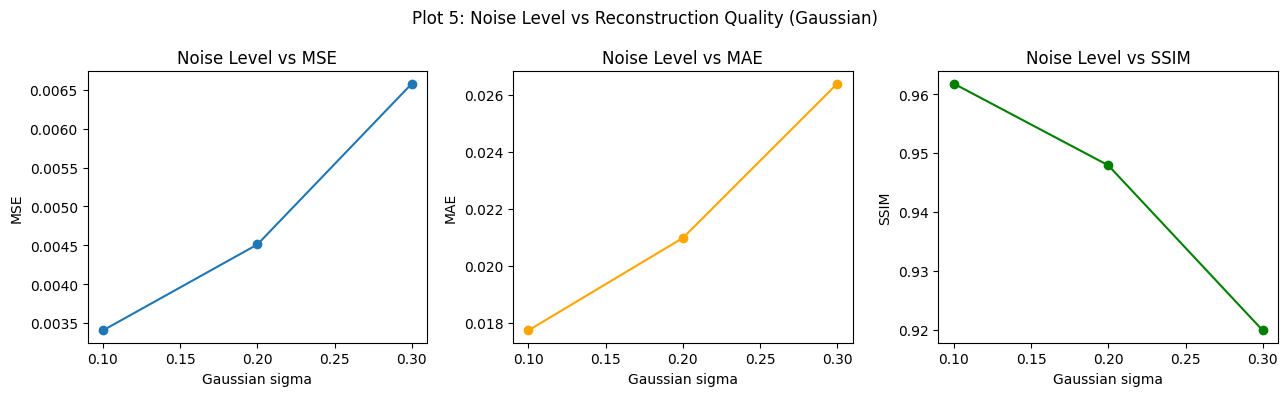

Saved results/results_denoise.json


In [ ]:
# 13. Plot 5: Noise Level vs Reconstruction Quality (Gaussian), and the analogous Salt-and-Pepper table

def evaluate_denoiser(model, clean_imgs, noisy_imgs):
    recon = model.predict(noisy_imgs, verbose=0)
    mse_v = mean_squared_error(clean_imgs.flatten(), recon.flatten())
    mae_v = mean_absolute_error(clean_imgs.flatten(), recon.flatten())
    ssim_scores = [ssim(clean_imgs[i].squeeze(), recon[i].squeeze(), data_range=1.0) for i in range(len(clean_imgs))]
    return float(mse_v), float(mae_v), float(np.mean(ssim_scores))

gauss_levels = [0.1, 0.2, 0.3]
gauss_results = {}
print("Noise Level (Gaussian sigma) | MSE      | MAE      | SSIM")
for sigma in gauss_levels:
    noisy = add_gaussian_noise(x_test_cnn, sigma=sigma, rng=np.random.default_rng(123))
    mse_v, mae_v, ssim_v = evaluate_denoiser(denoise_gauss_model, x_test_cnn, noisy)
    gauss_results[sigma] = {"mse": mse_v, "mae": mae_v, "ssim": ssim_v}
    print(f"{sigma:<29} | {mse_v:.6f} | {mae_v:.6f} | {ssim_v:.4f}")

sp_levels = [0.05, 0.10, 0.20]
sp_results = {}
print("\nNoise Level (Salt-and-Pepper p) | MSE      | MAE      | SSIM")
for p in sp_levels:
    noisy = add_salt_pepper_noise(x_test_cnn, p=p, rng=np.random.default_rng(123))
    mse_v, mae_v, ssim_v = evaluate_denoiser(denoise_sp_model, x_test_cnn, noisy)
    sp_results[p] = {"mse": mse_v, "mae": mae_v, "ssim": ssim_v}
    print(f"{p:<32} | {mse_v:.6f} | {mae_v:.6f} | {ssim_v:.4f}")

# Plot 5: three separate subplots (MSE, MAE, SSIM) vs Gaussian noise level
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(gauss_levels, [gauss_results[s]["mse"] for s in gauss_levels], marker="o")
axes[0].set_xlabel("Gaussian sigma"); axes[0].set_ylabel("MSE"); axes[0].set_title("Noise Level vs MSE")
axes[1].plot(gauss_levels, [gauss_results[s]["mae"] for s in gauss_levels], marker="o", color="orange")
axes[1].set_xlabel("Gaussian sigma"); axes[1].set_ylabel("MAE"); axes[1].set_title("Noise Level vs MAE")
axes[2].plot(gauss_levels, [gauss_results[s]["ssim"] for s in gauss_levels], marker="o", color="green")
axes[2].set_xlabel("Gaussian sigma"); axes[2].set_ylabel("SSIM"); axes[2].set_title("Noise Level vs SSIM")
fig.suptitle("Plot 5: Noise Level vs Reconstruction Quality (Gaussian)")
plt.tight_layout()
plt.savefig("figures/plot5_noise_level_vs_quality.png", dpi=150)
plt.show()

results_denoise = {
    "gaussian_denoiser": {
        "training_time_sec": denoise_gauss_train_time,
        "by_sigma": gauss_results,
        "history": {"loss": [float(v) for v in history_denoise_gauss.history["loss"]],
                    "val_loss": [float(v) for v in history_denoise_gauss.history["val_loss"]]}
    },
    "salt_pepper_denoiser": {
        "training_time_sec": denoise_sp_train_time,
        "by_p": sp_results,
        "history": {"loss": [float(v) for v in history_denoise_sp.history["loss"]],
                    "val_loss": [float(v) for v in history_denoise_sp.history["val_loss"]]}
    },
    "parameters": int(denoise_gauss_model.count_params())
}
with open("results/results_denoise.json", "w") as f:
    json.dump(results_denoise, f, indent=2)
print("Saved results/results_denoise.json")

In [ ]:
# 14. Build the Variational Autoencoder (VAE), latent dimension = 2 (for visualization)
LATENT_DIM_VAE = 2

class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + sigma * epsilon, epsilon ~ N(0, I)."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae_encoder(latent_dim=LATENT_DIM_VAE):
    inputs = layers.Input(shape=(28, 28, 1), name="vae_encoder_input")
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inputs)   # 14x14x32
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)        # 7x7x64
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(inputs, [z_mean, z_log_var, z], name="VAE_Encoder")

def build_vae_decoder(latent_dim=LATENT_DIM_VAE):
    latent_inputs = layers.Input(shape=(latent_dim,), name="vae_decoder_input")
    x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)  # 14x14x64
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)  # 28x28x32
    outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)     # 28x28x1
    return keras.Model(latent_inputs, outputs, name="VAE_Decoder")

vae_encoder = build_vae_encoder()
vae_decoder = build_vae_decoder()
vae_encoder.summary()
vae_decoder.summary()

class VAE(keras.Model):
    """Full VAE with a custom train_step implementing L = L_rec + L_KL (Section 16)."""
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.rec_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.rec_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, data):
        # Defensive unwrap: some Keras/TF versions pass validation data as a (x, y) tuple
        # even when y is None; if so, keep only the actual image tensor.
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        rec_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = rec_loss + kl_loss
        return total_loss, rec_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, rec_loss, kl_loss = self._compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.rec_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        total_loss, rec_loss, kl_loss = self._compute_losses(data)
        self.total_loss_tracker.update_state(total_loss)
        self.rec_loss_tracker.update_state(rec_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.rec_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 14, 14,    │        320 │ vae_encoder_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_decoder_input (InputLayer)  │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - kl_loss: 2.4160 - loss: 297.1809 - reconstruction_loss: 294.7648 - val_kl_loss: 1.6013 - val_loss: 213.7920 - val_reconstruction_loss: 212.1907
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - kl_loss: 2.0955 - loss: 207.8184 - reconstruction_loss: 205.7228 - val_kl_loss: 2.8869 - val_loss: 202.8405 - val_reconstruction_loss: 199.9536
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - kl_loss: 2.8387 - loss: 201.3510 - reconstruction_loss: 198.5123 - val_kl_loss: 3.1488 - val_loss: 199.7785 - val_reconstruction_loss: 196.6297
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 180ms/step - kl_loss: 3.0881 - loss: 198.8408 - reconstruction_loss: 195.7527 - val_kl_loss: 3.4719 - val_loss: 197.9155 - val_reconstruction_loss: 194.4436
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - kl_loss: 3.1553 - loss: 197.2291 - reconstruction_loss: 194.0737 - val_kl_loss: 3.1744 - val_loss: 195.8590 - val_reconstruction_loss: 192.6846
Epoch

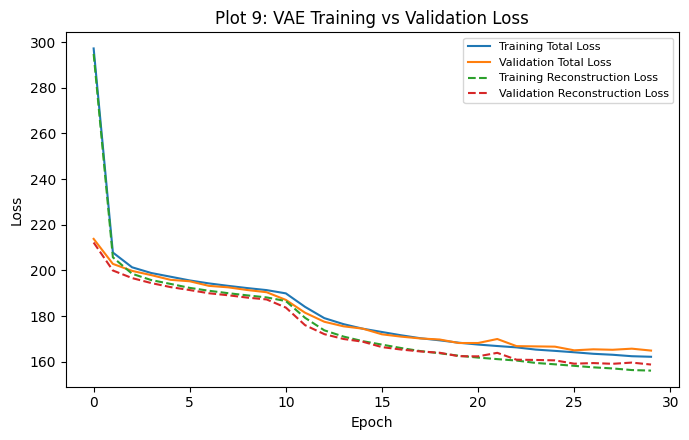

Final training   -> total: 162.17  recon: 156.11  kl: 6.0609
Final validation -> total: 164.88  recon: 158.77  kl: 6.1154


In [ ]:
# 15. Train the VAE (30 epochs, batch size 128) and time it
start_time = time.time()
history_vae = vae.fit(
    x_train_cnn,
    validation_data=x_test_cnn,   # bare array (not a tuple) -- matches x_train_cnn's structure
                                   # so our custom test_step receives a plain tensor, not (x, None)
    epochs=30, batch_size=128, verbose=1
)
vae_train_time = time.time() - start_time
print(f"\nVAE training time: {vae_train_time:.2f} seconds")

# Plot 9 (Section 22, item 9): Training/validation reconstruction loss for the VAE
plt.figure(figsize=(7, 4.5))
plt.plot(history_vae.history["loss"], label="Training Total Loss")
plt.plot(history_vae.history["val_loss"], label="Validation Total Loss")
plt.plot(history_vae.history["reconstruction_loss"], label="Training Reconstruction Loss", linestyle="--")
plt.plot(history_vae.history["val_reconstruction_loss"], label="Validation Reconstruction Loss", linestyle="--")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Plot 9: VAE Training vs Validation Loss")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/plot9_vae_loss_curve.png", dpi=150)
plt.show()

print(f"Final training   -> total: {history_vae.history['loss'][-1]:.2f}  "
      f"recon: {history_vae.history['reconstruction_loss'][-1]:.2f}  "
      f"kl: {history_vae.history['kl_loss'][-1]:.4f}")
print(f"Final validation -> total: {history_vae.history['val_loss'][-1]:.2f}  "
      f"recon: {history_vae.history['val_reconstruction_loss'][-1]:.2f}  "
      f"kl: {history_vae.history['val_kl_loss'][-1]:.4f}")

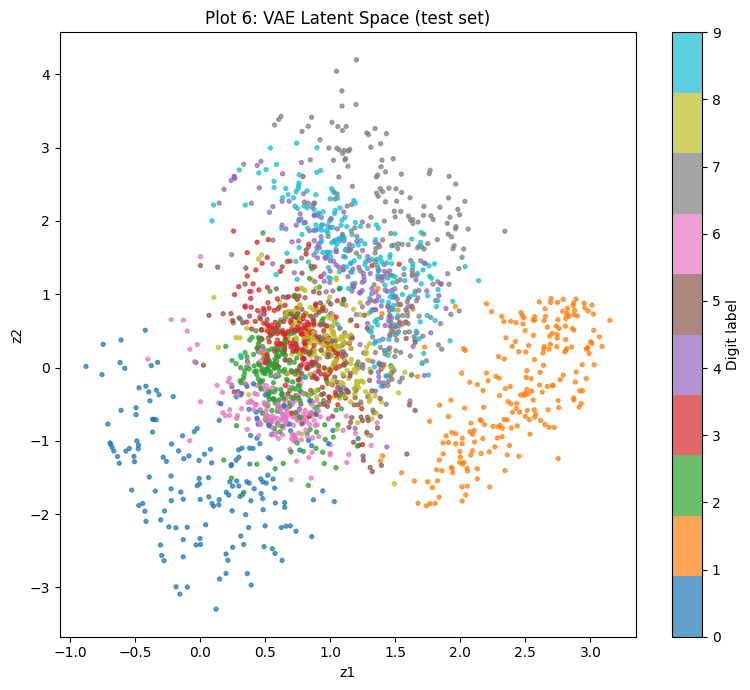

In [ ]:
# 16. Plot 6: VAE Latent Space visualization (test set, colored by digit label -- labels used only for plotting)
z_mean_test, z_log_var_test, z_test = vae_encoder.predict(x_test_cnn, verbose=0)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="Digit label", ticks=range(10))
plt.xlabel("z1"); plt.ylabel("z2")
plt.title("Plot 6: VAE Latent Space (test set)")
plt.tight_layout()
plt.savefig("figures/plot6_vae_latent_space.png", dpi=150)
plt.show()

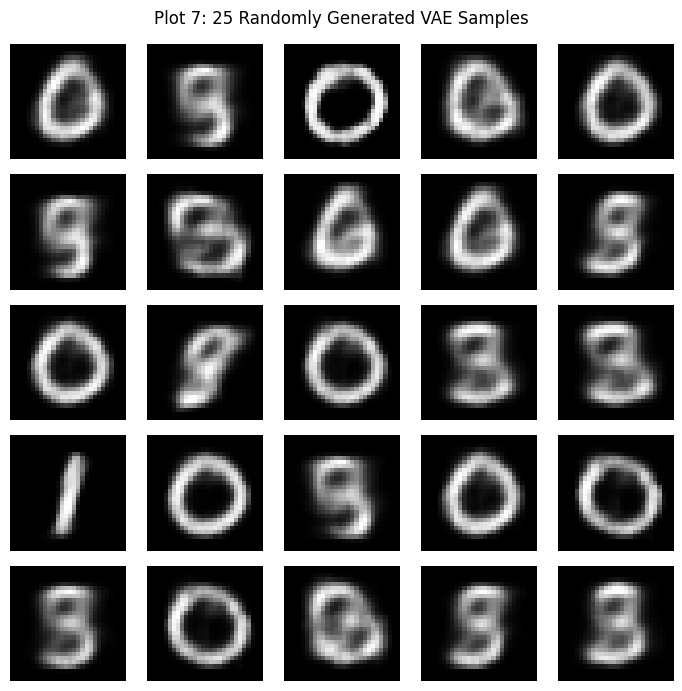

In [ ]:
# 17. Plot 7: Randomly Generated Images -- sample z ~ N(0, I), decode, display a 5x5 grid (>= 25 images)
n_gen = 25
rng = np.random.default_rng(42)
z_random = rng.normal(size=(n_gen, LATENT_DIM_VAE)).astype(np.float32)
generated_imgs = vae_decoder.predict(z_random, verbose=0).squeeze(-1)

fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_imgs[i], cmap="gray")
    ax.axis("off")
fig.suptitle("Plot 7: 25 Randomly Generated VAE Samples")
plt.tight_layout()
plt.savefig("figures/plot7_vae_generated_samples.png", dpi=150)
plt.show()

Interpolating between test image 0 (digit 9) and test image 1 (digit 3)


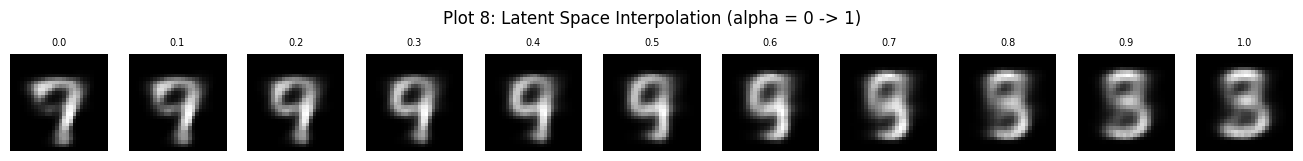

In [ ]:
# 18. Plot 8: Latent Space Interpolation between two encoded test digits
idx_a, idx_b = 0, 1   # two arbitrary test images (can be changed to specific digit indices)
z_A = z_mean_test[idx_a]
z_B = z_mean_test[idx_b]
print(f"Interpolating between test image {idx_a} (digit {y_test[idx_a]}) "
      f"and test image {idx_b} (digit {y_test[idx_b]})")

alphas = np.arange(0.0, 1.01, 0.1)
z_interp = np.array([(1 - a) * z_A + a * z_B for a in alphas], dtype=np.float32)
interp_imgs = vae_decoder.predict(z_interp, verbose=0).squeeze(-1)

fig, axes = plt.subplots(1, len(alphas), figsize=(len(alphas) * 1.2, 1.6))
for i, ax in enumerate(axes):
    ax.imshow(interp_imgs[i], cmap="gray")
    ax.set_title(f"{alphas[i]:.1f}", fontsize=7)
    ax.axis("off")
fig.suptitle("Plot 8: Latent Space Interpolation (alpha = 0 -> 1)")
plt.tight_layout()
plt.savefig("figures/plot8_vae_latent_interpolation.png", dpi=150)
plt.show()

In [ ]:
# 19. VAE reconstruction metrics on the test set (reported separately per Section 21)
vae_test_eval = vae.evaluate(x_test_cnn, verbose=0)  # [loss, reconstruction_loss, kl_loss]
vae_total_loss, vae_rec_loss, vae_kl_loss = vae_test_eval[0], vae_test_eval[1], vae_test_eval[2]

_, _, z_for_recon = vae_encoder.predict(x_test_cnn, verbose=0)
vae_recon_imgs_4d = vae_decoder.predict(z_for_recon, verbose=0)
vae_recon_imgs = vae_recon_imgs_4d.squeeze(-1)

vae_mse = mean_squared_error(x_test_cnn.flatten(), vae_recon_imgs_4d.flatten())
vae_mae = mean_absolute_error(x_test_cnn.flatten(), vae_recon_imgs_4d.flatten())
vae_ssim_scores = [ssim(x_test[i], vae_recon_imgs[i], data_range=1.0) for i in range(len(x_test))]
vae_mean_ssim = float(np.mean(vae_ssim_scores))
vae_params = vae_encoder.count_params() + vae_decoder.count_params()

print("VAE Metric              Value")
print(f"Reconstruction Loss     {vae_rec_loss:.4f}")
print(f"KL Loss                 {vae_kl_loss:.4f}")
print(f"Total Loss              {vae_total_loss:.4f}")
print(f"Test MSE                {vae_mse:.6f}")
print(f"Test MAE                {vae_mae:.6f}")
print(f"Mean SSIM               {vae_mean_ssim:.4f}")
print(f"Parameters              {vae_params}")

results_vae = {
    "model": "VAE",
    "reconstruction_loss": float(vae_rec_loss), "kl_loss": float(vae_kl_loss),
    "total_loss": float(vae_total_loss),
    "mse": float(vae_mse), "mae": float(vae_mae), "mean_ssim": vae_mean_ssim,
    "parameters": int(vae_params), "training_time_sec": vae_train_time,
    "history": {k: [float(v) for v in vv] for k, vv in history_vae.history.items()}
}
with open("results/results_vae.json", "w") as f:
    json.dump(results_vae, f, indent=2)
print("Saved results/results_vae.json")

VAE Metric              Value
Reconstruction Loss     6.1166
KL Loss                 164.6184
Total Loss              158.5019
Test MSE                0.047592
Test MAE                0.107062
Mean SSIM               0.4779
Parameters              134165
Saved results/results_vae.json


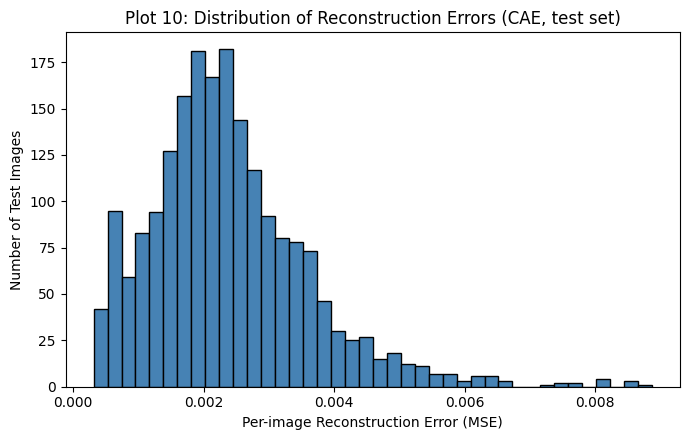

Reconstruction error -> min: 0.000313, max: 0.008873, mean: 0.002392, std: 0.001222


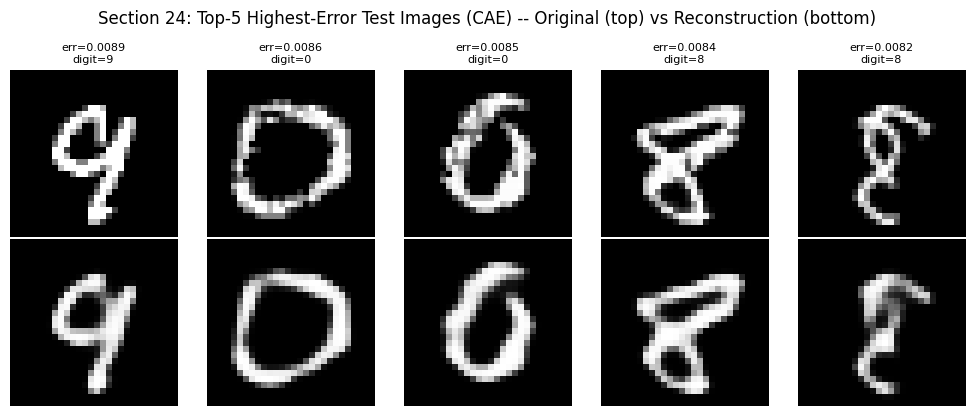

Top-5 highest-error test images (index, digit, error):
  index=949, digit=9, error=0.008873
  index=1317, digit=0, error=0.008593
  index=1962, digit=0, error=0.008475
  index=152, digit=8, error=0.008445
  index=287, digit=8, error=0.008165


In [ ]:
# 20. Plot 10 (Section 22 item 10): Reconstruction-error distribution on the test set.
#     Computed for the Convolutional Autoencoder (the primary deterministic reconstruction model).
per_image_error = np.mean((x_test_cnn - recon_cae_test) ** 2, axis=(1, 2, 3))  # e_i, Section 23

plt.figure(figsize=(7, 4.5))
plt.hist(per_image_error, bins=40, color="steelblue", edgecolor="black")
plt.xlabel("Per-image Reconstruction Error (MSE)")
plt.ylabel("Number of Test Images")
plt.title("Plot 10: Distribution of Reconstruction Errors (CAE, test set)")
plt.tight_layout()
plt.savefig("figures/plot10_reconstruction_error_hist.png", dpi=150)
plt.show()

print(f"Reconstruction error -> min: {per_image_error.min():.6f}, "
      f"max: {per_image_error.max():.6f}, mean: {per_image_error.mean():.6f}, "
      f"std: {per_image_error.std():.6f}")

# Section 24: Five test images with the largest reconstruction error
top5_idx = np.argsort(per_image_error)[-5:][::-1]
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for col, idx in enumerate(top5_idx):
    axes[0, col].imshow(x_test[idx], cmap="gray"); axes[0, col].axis("off")
    axes[1, col].imshow(recon_cae_test_imgs[idx], cmap="gray"); axes[1, col].axis("off")
    axes[0, col].set_title(f"err={per_image_error[idx]:.4f}\ndigit={y_test[idx]}", fontsize=8)
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstruction")
fig.suptitle("Section 24: Top-5 Highest-Error Test Images (CAE) -- Original (top) vs Reconstruction (bottom)")
plt.tight_layout()
plt.savefig("figures/high_error_images_top5.png", dpi=150)
plt.show()

print("Top-5 highest-error test images (index, digit, error):")
for idx in top5_idx:
    print(f"  index={idx}, digit={y_test[idx]}, error={per_image_error[idx]:.6f}")


--- Training FC-AE with latent dimension 2 ---
dz=2: MSE=0.051854  SSIM=0.4155  Params=210130

--- Training FC-AE with latent dimension 8 ---
dz=8: MSE=0.030857  SSIM=0.6559  Params=210520

--- Training FC-AE with latent dimension 16 ---
dz=16: MSE=0.022420  SSIM=0.7415  Params=211040

--- Training FC-AE with latent dimension 32 ---
dz=32: MSE=0.021391  SSIM=0.7541  Params=212080

Latent Dimension | MSE      | SSIM   | Parameters
2                 | 0.051854 | 0.4155 | 210130
8                 | 0.030857 | 0.6559 | 210520
16                | 0.022420 | 0.7415 | 211040
32                | 0.021391 | 0.7541 | 212080


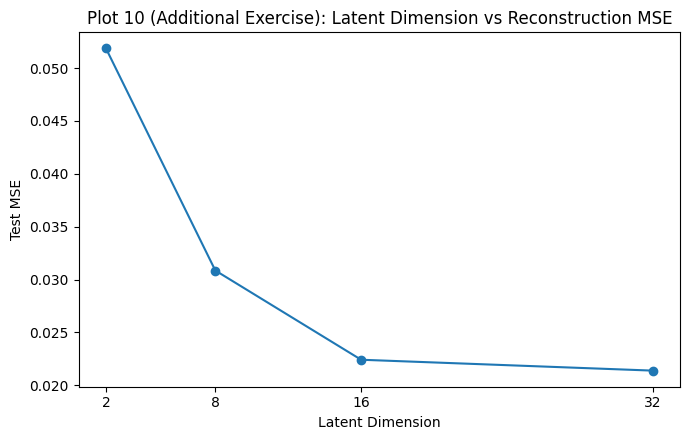

Saved results/results_latent_dim_study.json


In [ ]:
# 21. Additional Latent-Dimension Study (Section 27): repeat the FC autoencoder with dz in {2, 8, 16, 32}
latent_dims = [2, 8, 16, 32]
latent_dim_results = {}

for dz in latent_dims:
    print(f"\n--- Training FC-AE with latent dimension {dz} ---")
    tf.random.set_seed(42)
    model_dz = build_fc_autoencoder(latent_dim=dz)
    model_dz.fit(x_train_flat, x_train_flat,
                 validation_data=(x_test_flat, x_test_flat),
                 epochs=15, batch_size=128, verbose=0)
    recon_dz = model_dz.predict(x_test_flat, verbose=0)
    recon_dz_imgs = recon_dz.reshape((-1, 28, 28))
    mse_dz = mean_squared_error(x_test_flat.flatten(), recon_dz.flatten())
    ssim_dz = float(np.mean([ssim(x_test[i], recon_dz_imgs[i], data_range=1.0) for i in range(len(x_test))]))
    params_dz = model_dz.count_params()
    latent_dim_results[dz] = {"mse": float(mse_dz), "ssim": ssim_dz, "parameters": int(params_dz)}
    print(f"dz={dz}: MSE={mse_dz:.6f}  SSIM={ssim_dz:.4f}  Params={params_dz}")
    keras.backend.clear_session()

print("\nLatent Dimension | MSE      | SSIM   | Parameters")
for dz in latent_dims:
    r = latent_dim_results[dz]
    print(f"{dz:<17} | {r['mse']:.6f} | {r['ssim']:.4f} | {r['parameters']}")

# Plot 10 (Section 27): Latent Dimension vs Reconstruction MSE
plt.figure(figsize=(7, 4.5))
plt.plot(latent_dims, [latent_dim_results[d]["mse"] for d in latent_dims], marker="o")
plt.xlabel("Latent Dimension"); plt.ylabel("Test MSE")
plt.title("Plot 10 (Additional Exercise): Latent Dimension vs Reconstruction MSE")
plt.xticks(latent_dims)
plt.tight_layout()
plt.savefig("figures/plot10_latentdim_vs_mse.png", dpi=150)
plt.show()

with open("results/results_latent_dim_study.json", "w") as f:
    json.dump(latent_dim_results, f, indent=2)
print("Saved results/results_latent_dim_study.json")

# Re-build the FC-AE at LATENT_DIM_FC = 16 was already trained above as fc_ae; keep it as the reported model.

In [ ]:
# 22. Consolidated Results (Section 25)
consolidated = {
    "FC Autoencoder": {
        "MSE": fc_mse, "MAE": fc_mae, "SSIM": fc_mean_ssim,
        "Parameters": fc_params, "Time (s)": fc_train_time
    },
    "Conv. Autoencoder": {
        "MSE": cae_mse, "MAE": cae_mae, "SSIM": cae_mean_ssim,
        "Parameters": cae_params, "Time (s)": cae_train_time
    },
    "Denoising CAE (Gaussian, avg over sigma)": {
        "MSE": float(np.mean([gauss_results[s]["mse"] for s in gauss_levels])),
        "MAE": float(np.mean([gauss_results[s]["mae"] for s in gauss_levels])),
        "SSIM": float(np.mean([gauss_results[s]["ssim"] for s in gauss_levels])),
        "Parameters": denoise_gauss_model.count_params(), "Time (s)": denoise_gauss_train_time
    },
    "VAE": {
        "MSE": vae_mse, "MAE": vae_mae, "SSIM": vae_mean_ssim,
        "Parameters": vae_params, "Time (s)": vae_train_time
    },
}

print(f"{'Model':<42}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Params':>12}{'Time(s)':>10}")
for name, r in consolidated.items():
    print(f"{name:<42}{r['MSE']:>10.6f}{r['MAE']:>10.6f}{r['SSIM']:>10.4f}{r['Parameters']:>12}{r['Time (s)']:>10.2f}")

with open("results/results_consolidated.json", "w") as f:
    json.dump(consolidated, f, indent=2)
print("\nSaved results/results_consolidated.json")
print("\nAll figures saved under ./figures/  and all metrics saved under ./results/")

Model                                            MSE       MAE      SSIM      Params   Time(s)
FC Autoencoder                              0.021511  0.057644    0.7565      211040     40.54
Conv. Autoencoder                           0.002392  0.014598    0.9762       74497    693.63
Denoising CAE (Gaussian, avg over sigma)    0.004832  0.021695    0.9432       74497    655.22
VAE                                         0.047592  0.107062    0.4779      134165    531.87

Saved results/results_consolidated.json

All figures saved under ./figures/  and all metrics saved under ./results/
